In [ ]:
# NumPy, Pandas, Matplotlib, Seaborn, Mini Projet

# etudiants.csv, filieres.csv | ventes.csv, produits.csv, magasins.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path

# réglages
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA = Path("data")

if not (DATA / "ventes.csv").exists():
  from generer_donnees import generer_tout
  generer_tout(DATA)

Matplotlib is building the font cache; this may take a moment.


In [3]:
# plus rapidement !!! , vectorisé 

# liste python 

# - éléments de tous les types 
# - chaque élément est un objet éparpillé 
# - les boucles sont lentes 

# numpy
# - un seuil type 
# - bloc mémoire contigu


Liste Python :    58.6 ms
Numpy :     0.7 ms -> 81.040344x plus rapide


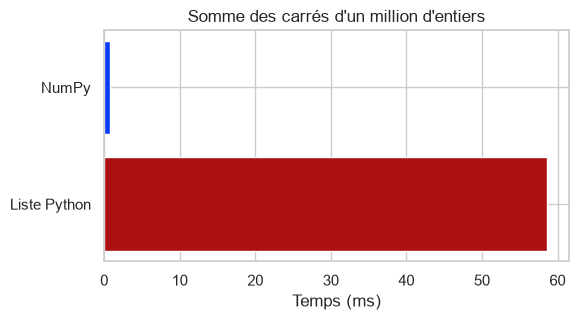

In [22]:
import time 

# somme des carrés d'un million d'entiers

n = 1_000_000
liste = list(range(n))
tableau = np.arange(n)


t0 = time.perf_counter(); s1 = sum(x ** 2 for x in liste); t_liste = time.perf_counter() - t0

t0 = time.perf_counter()
s2 =(tableau ** 2).sum()
t_numpy = time.perf_counter() - t0

print(f"Liste Python : {t_liste * 1000:7.1f} ms")
print(f"Numpy : {t_numpy * 1000:7.1f} ms -> {t_liste / t_numpy:0f}x plus rapide")

fig, ax = plt.subplots(figsize=(6,3))

ax.barh(["Liste Python", "NumPy"], [t_liste * 1000, t_numpy * 1000], color=["#AD1010", "#063BF9"])
ax.set_xlabel("Temps (ms)")
ax.set_title("Somme des carrés d'un million d'entiers")
plt.show()

In [ ]:
# Tableau  --> lignes, colonnes 

# shape : les dimensions du tableau : (3, 4) ==> 3 lignes et 4 colonnes
# ndim : son nombre d'axes 
# size : son nombre d'éléments 
# dtype : le type des éléments 

## Fonctions

# np.array ==> np.array([1, 2, 3])
# np.zeros, np.ones, np.full ==> np.zeros((3, 4)) | np.full((3,4), None)
# np.arange  ==> np.arange(0, 100, 2) ==> [0, 2, 4, 6 ... ]
# np.linspace ==> 
# np.eye ==> np.eye(3)

In [32]:
a = np.array([12, 15, 9, 17])
M = np.array([[1,2,3],
              [4,5,6]])

for nom, t in [("a", a), ("M", M)]:
  print(f"{nom}: shape={t.shape}, ndim={t.ndim}, size={t.size}, dtype={t.dtype}")


print("\nzeros:\n", np.zeros((3, 4), dtype=int))
print("arange:", np.arange(0, 20, 5))
print("linspace:", np.linspace(0,1,5))
print("identité : \n", np.eye(3, dtype=int))

a: shape=(4,), ndim=1, size=4, dtype=int64
M: shape=(2, 3), ndim=2, size=6, dtype=int64

zeros:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
arange: [ 0  5 10 15]
linspace: [0.   0.25 0.5  0.75 1.  ]
identité : 
 [[1 0 0]
 [0 1 0]
 [0 0 1]]


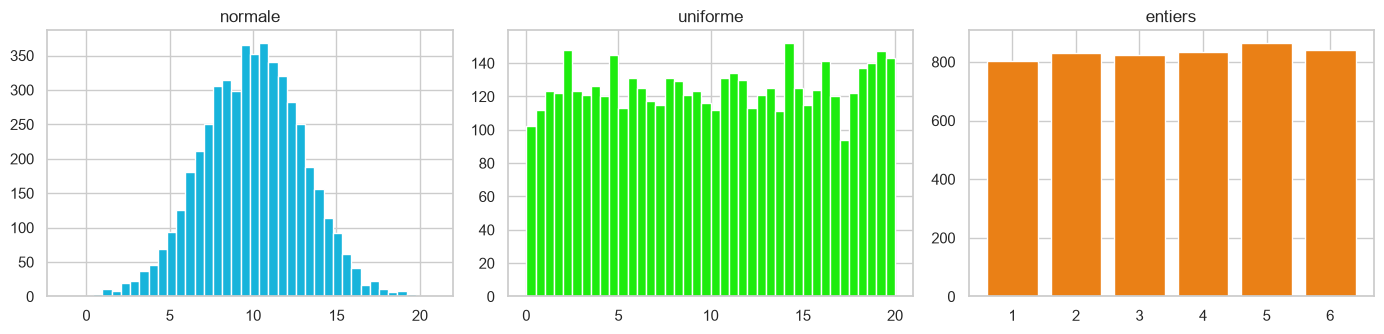

In [ ]:
rng = np.random.default_rng(2026) # <-- graine, seed 

normale = rng.normal(loc=10, scale=3, size=5_000) 
uniforme = rng.uniform(low=0, high=20, size=5_000) 
entiers = rng.integers(1, 7, size=5_000) 

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(normale, bins=40, color="#17B4DB"); axes[0].set_title("normale")
axes[1].hist(uniforme, bins=40, color="#1DEC0E"); axes[1].set_title("uniforme")
axes[2].hist(entiers, bins=np.arange(0.5, 7.5), rwidth=0.8, color="#EA8016"); axes[2].set_title("entiers")
plt.tight_layout()
plt.show()

### Exercice 1.1 — Créer des tableaux

Les températures moyennes mensuelles (fictives) d'une ville côtière sont :
`[27.3, 28.1, 28.6, 28.2, 27.4, 26.1, 25.4, 25.3, 25.9, 26.8, 27.6, 27.4]`

1. Transformez cette liste en tableau `temp` et affichez `shape`, `ndim` et `dtype`.
2. Créez `mois`, les entiers de 1 à 12, avec `np.arange`.
3. Créez 7 valeurs régulièrement espacées entre 0 et 3 avec `np.linspace`.
4. Transformez `temp` en matrice 4 × 3 (un trimestre par ligne).
5. Avec un générateur de graine 0, simulez 1 000 notes suivant une loi normale de moyenne 11 et d'écart-type 3.

In [38]:
temp = np.array([27.3, 28.1, 28.6, 28.2, 27.4, 26.1, 25.4, 25.3, 25.9, 26.8, 27.6, 27.4])
print(temp.shape, temp.ndim, temp.dtype)

mois = np.arange(1, 13)
print(mois)

print(np.linspace(0, 3, 7))

# reshape 
trimestres = temp.reshape(4, 3)
print(trimestres)

rng0 = np.random.default_rng(0)
notes_sim = rng0.normal(11, 3, 1_000)
print(notes_sim[:5].round(2), " moyenne = ", notes_sim.mean().round(2))

(12,) 1 float64
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[0.  0.5 1.  1.5 2.  2.5 3. ]
[[27.3 28.1 28.6]
 [28.2 27.4 26.1]
 [25.4 25.3 25.9]
 [26.8 27.6 27.4]]
[11.38 10.6  12.92 11.31  9.39]  moyenne =  10.86


### Indexation, découpage et masque boolean 

In [ ]:
# tableau [lignes, colonnes] <--> debut:fin:pas 

# Si X est le tableau

# X[0] ==> première ligne 
# X[:, 1] ==> deuxième colonne
# X[1:3, :2] ==> ligne 1, 2 colonne 0, 1
# X[[0, 4]] ==> lignes 0 et 4
# X[X > 10] ==> masque booléan
# np.where(cond, a, b) ==> a si la condition est vraie et b sinon


In [57]:
# matrice 8 étudiants et 4 matières

rng = np.random.default_rng(7)
notes = rng.integers(3, 20, size=(8, 4)).astype(float)
matières = np.array(["Python", "Stats", "Algèbre", "Anglais"])
print(notes)

print("\nÉtudiant n°0 :", notes[0])
print("Colonne Stats: ", notes[:, 1])
print("Etudiants 2 à 4, deux premières matières: \n", notes[2:5, :2])
print("Etudiants 0 et 7: \n", notes[[0, 7]])

# qui a eu au moins 12 en python 
masque = notes[:, 0] >= 12.
print("\n Masque : ", masque)
print("Lignes concernées : \n", notes[masque])
print("Nb de notes < 8 :", (notes < 8).sum())

plafonnees = np.where(notes > 18, 18, notes)
print(plafonnees)



[[19. 13. 14. 18.]
 [12. 16. 17.  6.]
 [ 3.  8.  7. 17.]
 [18.  3. 11. 16.]
 [ 5. 16.  5. 10.]
 [16.  8.  8.  7.]
 [15.  7. 19. 10.]
 [11. 11. 12. 12.]]

Étudiant n°0 : [19. 13. 14. 18.]
Colonne Stats:  [13. 16.  8.  3. 16.  8.  7. 11.]
Etudiants 2 à 4, deux premières matières: 
 [[ 3.  8.]
 [18.  3.]
 [ 5. 16.]]
Etudiants 0 et 7: 
 [[19. 13. 14. 18.]
 [11. 11. 12. 12.]]

 Masque :  [ True  True False  True False  True  True False]
Lignes concernées : 
 [[19. 13. 14. 18.]
 [12. 16. 17.  6.]
 [18.  3. 11. 16.]
 [16.  8.  8.  7.]
 [15.  7. 19. 10.]]
Nb de notes < 8 : 8
[[18. 13. 14. 18.]
 [12. 16. 17.  6.]
 [ 3.  8.  7. 17.]
 [18.  3. 11. 16.]
 [ 5. 16.  5. 10.]
 [16.  8.  8.  7.]
 [15.  7. 18. 10.]
 [11. 11. 12. 12.]]


In [64]:
# vue / copie 

x = np.arange(6) 
print("x d'origine :", x)
vue = x[:3]
vue[0] = 99
print("x après modification : ", x)

print("\n")

y = np.arange(6)
print("y d'origine :", y)
copie = y[:3].copy()
copie[0] = 99
print("y après modification de la copie: ", y)

x d'origine : [0 1 2 3 4 5]
x après modification :  [99  1  2  3  4  5]


y d'origine : [0 1 2 3 4 5]
y après modification de la copie:  [0 1 2 3 4 5]


### Exercice 1.2 — Indexer et filtrer

En utilisant la matrice `notes` ci-dessus :
1. Affichez les notes du **troisième** étudiant.
2. Affichez les notes d'**Algèbre** de tous les étudiants.
3. Quels étudiants (indices) ont **au moins 12 en Python ET au moins 10 en Stats** ? *(opérateur `&` et `np.flatnonzero`)*
4. Créez `notes_rattrapage` : toute note inférieure à 8 est remplacée par 8 (sans modifier `notes`).
5. Combien de notes sont comprises entre 10 et 15 inclus ?

In [67]:
rng = np.random.default_rng(7)
notes = rng.integers(3, 20, size=(8, 4)).astype(float)
matières = np.array(["Python", "Stats", "Algèbre", "Anglais"])

print(notes[2])
print(notes[:2])

cond = (notes[:, 0] >= 12) & (notes[:, 1] >= 10)
print("Indices :", np.flatnonzero(cond)) 

notes_rattrapage = np.where(notes < 8, 8, notes)
print(notes_rattrapage)

total = ((notes >= 10) & (notes <= 15)).sum()
print("Notes entre 10 et 15 inclus : ", total)

[ 3.  8.  7. 17.]
[[19. 13. 14. 18.]
 [12. 16. 17.  6.]]
Indices : [0 1]
[[19. 13. 14. 18.]
 [12. 16. 17.  8.]
 [ 8.  8.  8. 17.]
 [18.  8. 11. 16.]
 [ 8. 16.  8. 10.]
 [16.  8.  8.  8.]
 [15.  8. 19. 10.]
 [11. 11. 12. 12.]]
Notes entre 10 et 15 inclus :  11


### Vectorisation et broadcasting 

In [ ]:
prix_fcfa = np.array([4500, 1300, 800, 600, 12000])

# 1€ = 655.957 fcfa 
print("Prix en euros :", (prix_fcfa / 655.957).round(2))
print("Prix TTC (18%) :", (prix_fcfa * 1.18))
print("Racines :", np.sqrt(prix_fcfa).round(1))

Prix en euros : [ 6.86  1.98  1.22  0.91 18.29]
Prix TTC (18%) : [ 5310.  1534.   944.   708. 14160.]
Racines : [ 67.1  36.1  28.3  24.5 109.5]
